# <center> <img src="figs/LogoUFSCar.jpg" alt="Logo UFScar" width="110" align="left"/>  <br/> <center>Universidade Federal de São Carlos (UFSCar)<br/><font size="4"> Departamento de Computação, campus Sorocaba</center></font>
</p>

<font size="4"><center><b>Disciplina: Aprendizado de Máquina</b></center></font>
  
<font size="3"><center>Prof. Dr. Tiago A. Almeida</center></font>

## <center>Projeto Final</center>

**Nome**: Juan Pedro

**RA**: 823164


---
### Análise exploratória

Nesta seção, deve ser feita a leitura da base de dados e todas as análises necessárias para interpretar e analisar os dados, tais como:
* Significado de cada atributo
* Medidas descritivas
* Gráficos

#### **1. Configuração Inicial**

Primeiro, vamos executar esta célula para carregar a extensão [autoreload](https://ipython.readthedocs.io/en/stable/config/extensions/autoreload.html?highlight=autoreload). Isso nos permite editar arquivos de origem `.py` e reimportá-los para o notebook para uma experiência de edição e depuração perfeita.

In [1]:
%load_ext autoreload
%autoreload 2

Agora podemos importar as bibliotecas que usaremos para a análise e visualização dos dados.

In [2]:
# Caminho dos arquivos
FILES_DIRECTORY = "dados"

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configurações de visualização
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

#### **2. Análise dos Arquivos de Metadados**

Vamos carregar e analisar os arquivos que descrevem o problema: `train.csv` (amostras de treino), `Data_Dictionary.csv` (significado dos dados) e `users_info.txt` (informações dos sujeitos).


##### 2.1. Conjunto de Treinamento (`train.csv`)

Este arquivo contém os IDs das amostras e suas respectivas classes (o nosso alvo de previsão).

In [3]:
# Carregar os dados de treino
df_train = pd.read_csv(os.path.join(FILES_DIRECTORY, 'train.csv'))

# Exibir as primeiras linhas
print("--- Primeiras linhas do train.csv ---")
display(df_train.head())

# Exibir informações gerais
print("\n--- Informações do train.csv ---")
df_train.info()

--- Primeiras linhas do train.csv ---


,Id,Label
0,U_79201,STRESS
1,U_56491,ANAEROBIC
2,U_94628,ANAEROBIC
3,U_97819,AEROBIC
4,U_96956,STRESS



--- Informações do train.csv ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Id      75 non-null     object
 1   Label   75 non-null     object
dtypes: object(2)
memory usage: 1.3+ KB


##### Medida Descritiva: Distribuição das Classes
Vamos verificar quantas amostras existem para cada classe (`STRESS`, `AEROBIC`, `ANAEROBIC`). Isso é crucial para saber se os dados estão balanceados.


--- Contagem por Classe ---


Label
ANAEROBIC    28
STRESS       25
AEROBIC      22
Name: count, dtype: int64

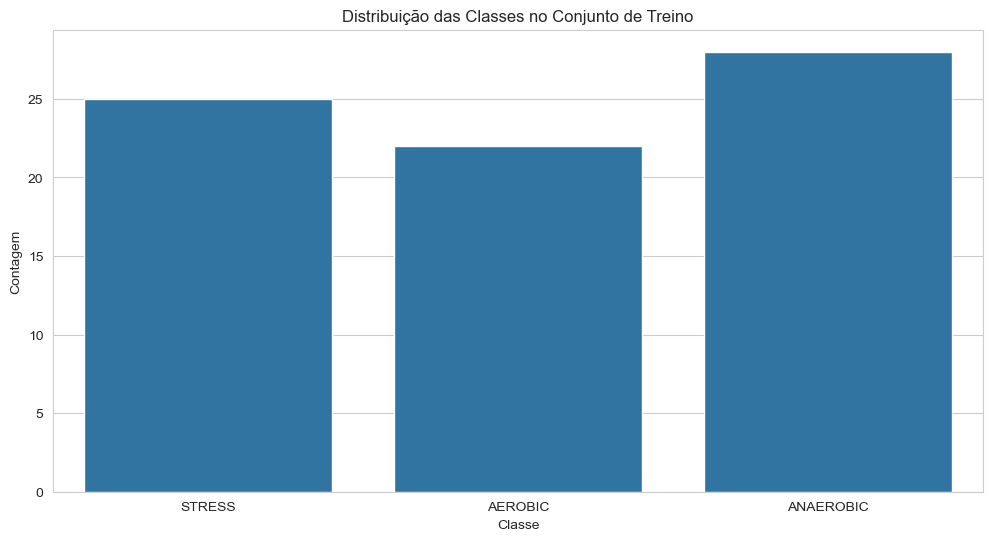

In [4]:
# Contagem de cada classe
print("\n--- Contagem por Classe ---")
display(df_train['Label'].value_counts())

# Gráfico da distribuição das classes
plt.title('Distribuição das Classes no Conjunto de Treino')
sns.countplot(x='Label', data=df_train, order=['STRESS', 'AEROBIC', 'ANAEROBIC'])
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.show()

##### 2.2. Dicionário de Dados (`Data_Dictionary.csv`)

Este arquivo é fundamental, pois explica o significado de cada atributo que foi coletado pelos sensores.

In [5]:
# Carregar o dicionário de dados
df_dict = pd.read_csv(os.path.join(FILES_DIRECTORY, 'Data_Dictionary.csv'), encoding='latin1')

# Exibir o dicionário completo
print("--- Dicionário de Dados ---")
display(df_dict)

--- Dicionário de Dados ---


,Code,Variable Name,Description,Sampling Frequency (Hz),Units
0,EDA,Electrodermal Activity,Data from the electrodermal activity sensor,4,microsiemens (uS)
1,TEMP,Skin Temperature,Data from temperature sensor,4,Celsius (°C)
2,BVP,Blood Volume Pulse,Data from photoplethysmograph,64,-
3,HR,Heart Rate,Average heart rate extracted from the BVP signal,1,beats per minute (BPM)
4,IBI,Inter Beat Interval,Time between individuals heart beats extracted...,-,-
5,ACC,3-axis Accelerometer,Data from 3-axis accelerometer sensor (x;y;z),32,1/64g
6,tags,Event mark times,Each mark corresponds to a physical button pre...,-,-


#### **2.3. Informações dos Sujeitos (`users_info.txt`)**
Este arquivo contém dados demográficos (idade, gênero, etc.) dos sujeitos que participaram do experimento.

In [6]:
# Carregar os dados dos usuários, tratando valores ausentes e pulando o rodapé
df_users = pd.read_csv(
    os.path.join(FILES_DIRECTORY, 'users_info.txt'), 
    na_values='-',         # Trata o '-' como valor ausente (NaN)
    skipfooter=11,         # Pula as 11 linhas de rodapé
    engine='python'
)

# Exibir as primeiras linhas
print("\n--- Primeiras linhas do users_info.txt ---")
display(df_users.head())

# Medidas Descritivas da demografia
# (Agora as colunas de idade, altura e peso serão numéricas)
print("\n--- Medidas Descritivas (Demografia) ---")
display(df_users[['Age', 'Height (cm)', 'Weight (kg)']].describe())


--- Primeiras linhas do users_info.txt ---


,Id,Gender,Age,Height (cm),Weight (kg),Does physical activity regularly?,Protocol,Stress Inducement,Aerobic Exercise,Anaerobic Exercise
0,U_21920,m,22.0,173.0,78.0,Yes,V1,Yes,Yes,Yes
1,U_27250,m,20.0,185.0,95.0,No,V1,Yes****,Yes,Yes
2,U_82422,f,NaN,NaN,NaN,NaN,V2,Yes,NaN,NaN
3,U_35900,m,21.0,175.0,65.0,Yes,V1,Yes,Yes,Yes
4,U_30402,m,21.0,174.0,70.0,Yes,V1,Yes,Yes,Yes



--- Medidas Descritivas (Demografia) ---


,Age,Height (cm),Weight (kg)
count,93.000000,93.000000,93.000000
mean,22.365591,171.602151,69.451613
std,3.516375,9.362436,12.842284
min,18.000000,152.000000,47.000000
25%,21.000000,165.000000,61.000000
50%,21.000000,173.000000,65.000000
75%,22.000000,176.000000,80.000000
max,31.000000,192.000000,97.000000


##### Gráficos: Análise Demográfica

Vamos visualizar a distribuição de idade, gênero e outras características dos participantes.

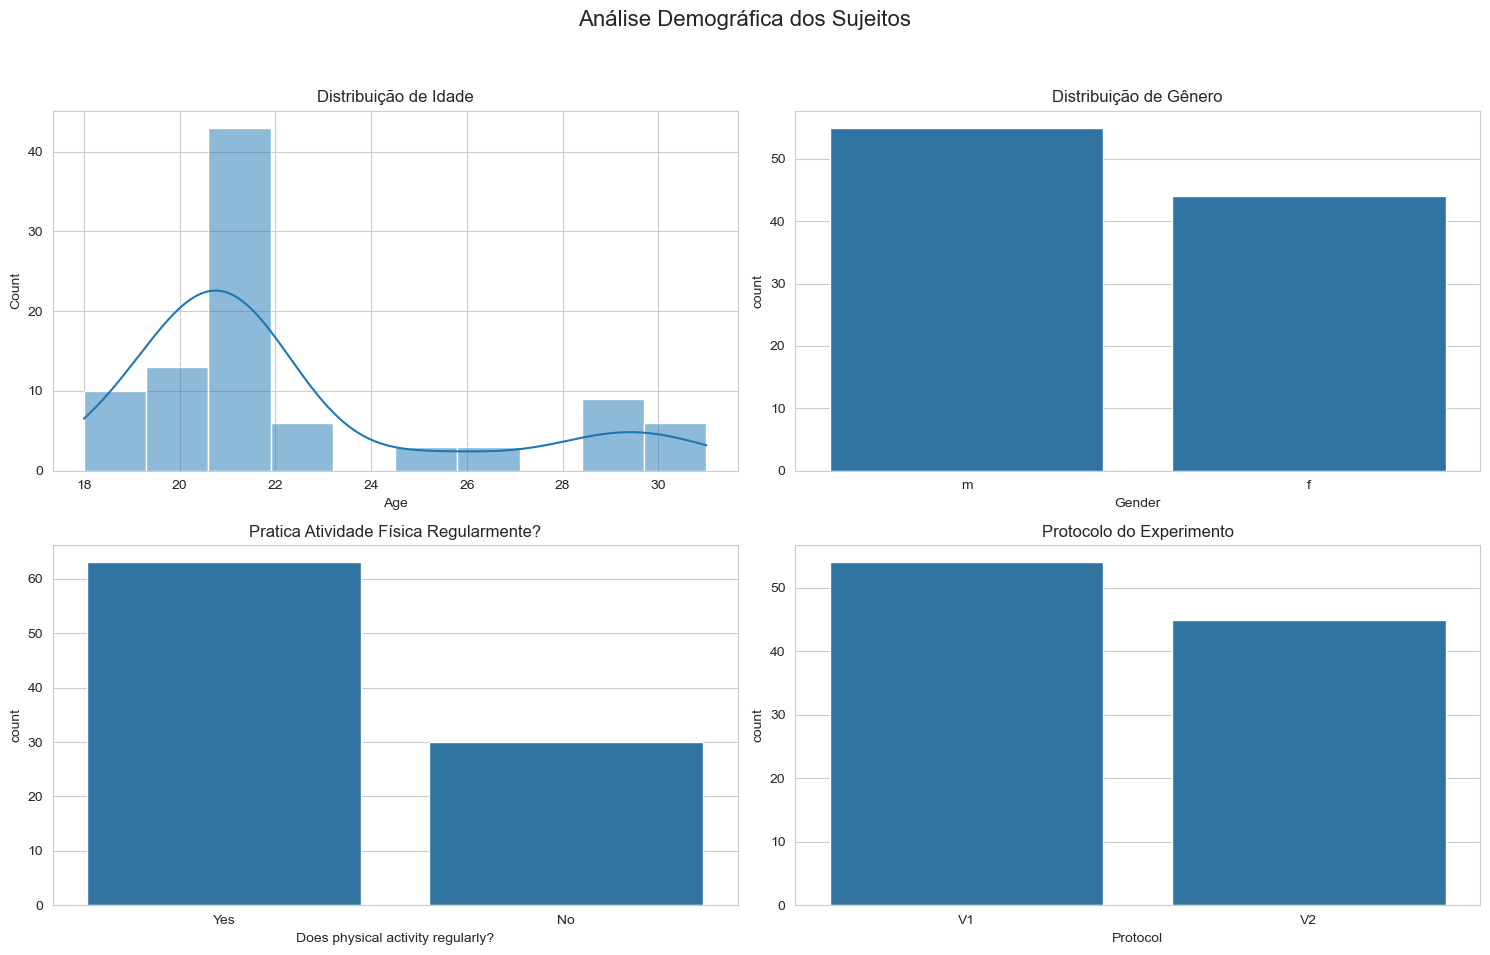

In [7]:
from scripts.analise_exploratoria import plot_demographics

plot_demographics(df_users)

#### **3. Análise dos Dados Brutos (Exemplo: Amostra `U_79201`)**

##### 3.1. Carregando e Descrevendo os Sinais
Vamos carregar todos os sinais disponíveis para o sujeito `U_79201` e ver suas medidas descritivas (média, min, max, etc.).

In [8]:
from scripts.preprocessamento import load_sensor_data

USER_ID = 'U_79201'
USER_FOLDER = f'{FILES_DIRECTORY}/wearables/{USER_ID}/'

# Carregar todos os sinais
df_acc = load_sensor_data(USER_FOLDER, 'ACC.csv', ['X', 'Y', 'Z'])
df_bvp = load_sensor_data(USER_FOLDER, 'BVP.csv', ['BVP'])
df_eda = load_sensor_data(USER_FOLDER, 'EDA.csv', ['EDA'])
df_hr = load_sensor_data(USER_FOLDER, 'HR.csv', ['HR'])
df_ibi = load_sensor_data(USER_FOLDER, 'IBI.csv', ['IBI'])
df_temp = load_sensor_data(USER_FOLDER, 'TEMP.csv', ['TEMP'])

# --- Medidas Descritivas dos Sinais ---

print(f"--- Medidas Descritivas para o Sujeito {USER_ID} ---")

if not df_acc.empty:
    print("\nAcelerômetro (ACC):")
    # Calcular a magnitude do vetor de aceleração
    df_acc['Mag'] = (df_acc['X']**2 + df_acc['Y']**2 + df_acc['Z']**2)**0.5
    print(df_acc[['X', 'Y', 'Z', 'Mag']].describe())

if not df_eda.empty:
    print("\nAtividade Eletrodérmica (EDA):")
    print(df_eda['EDA'].describe())

if not df_hr.empty:
    print("\nFrequência Cardíaca (HR):")
    print(df_hr['HR'].describe())

if not df_temp.empty:
    print("\nTemperatura da Pele (TEMP):")
    print(df_temp['TEMP'].describe())

if not df_bvp.empty:
    print("\nPulso de Volume Sanguíneo (BVP):")
    print(df_bvp['BVP'].describe())

if not df_ibi.empty:
    print("\nIntervalo Inter-batimento (IBI):")
    print(df_ibi['IBI'].describe())

--- Medidas Descritivas para o Sujeito U_79201 ---

Acelerômetro (ACC):
                  X             Y             Z           Mag
count  51948.000000  51948.000000  51948.000000  51948.000000
mean     -44.501290    -12.289116     39.892566     63.758476
std        8.604691     12.388127     10.889542      1.934603
min     -105.000000    -73.000000    -71.000000     23.790755
25%      -51.000000    -17.000000     35.000000     63.188211
50%      -44.000000    -15.000000     44.000000     63.710282
75%      -38.000000    -11.000000     48.000000     64.202804
max       32.000000     95.000000     87.000000    113.586971

Atividade Eletrodérmica (EDA):
count    6492.000000
mean        2.189533
std         0.513896
min         0.000000
25%         1.777791
50%         2.085673
75%         2.658772
max         3.258435
Name: EDA, dtype: float64

Frequência Cardíaca (HR):
count    1614.000000
mean       98.881952
std        12.676421
min        52.000000
25%        93.520000
50%        9

##### 3.2. Gráficos: Visualizando os Sinais ao Longo do Tempo
Uma boa forma de entender os dados é plotá-los em série temporal.

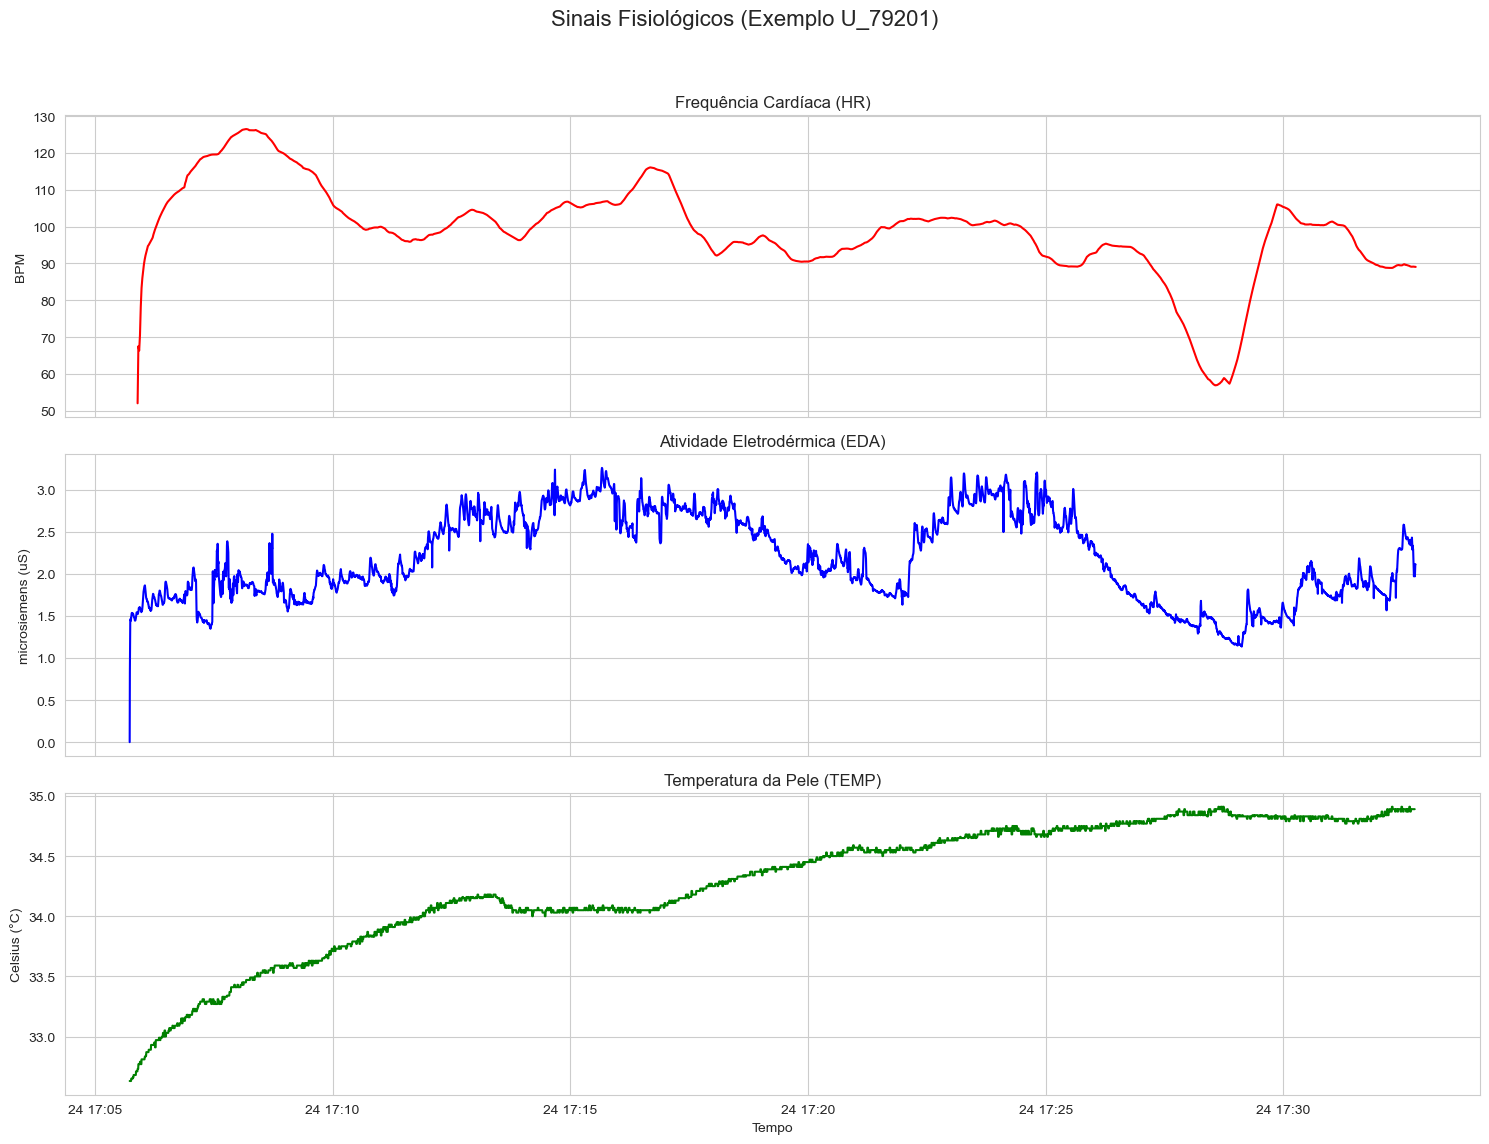

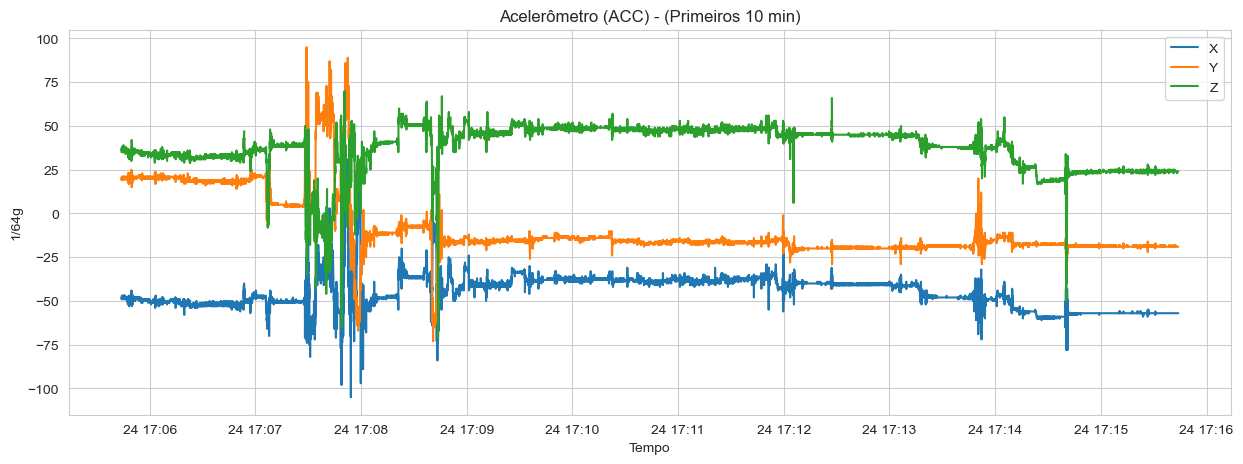

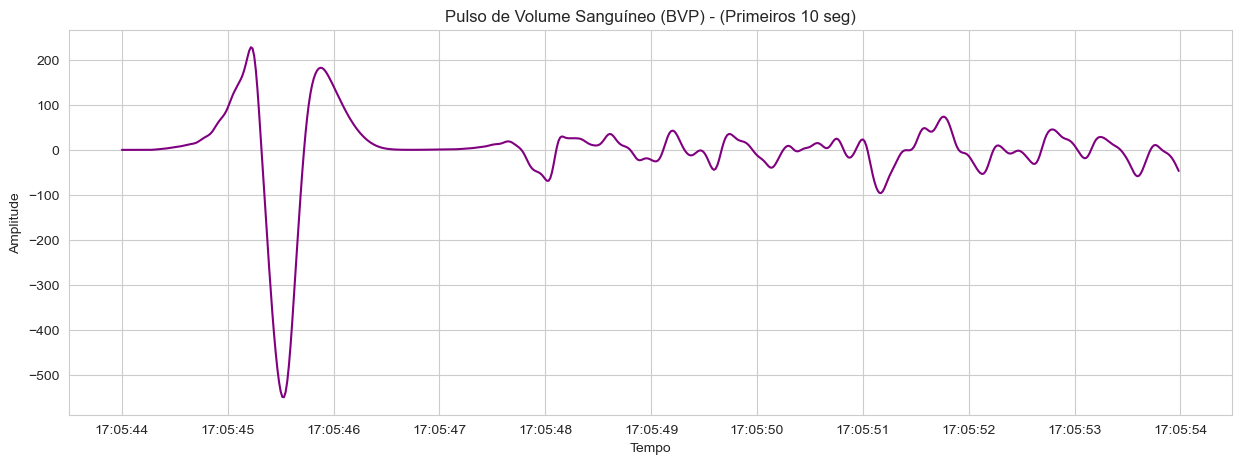

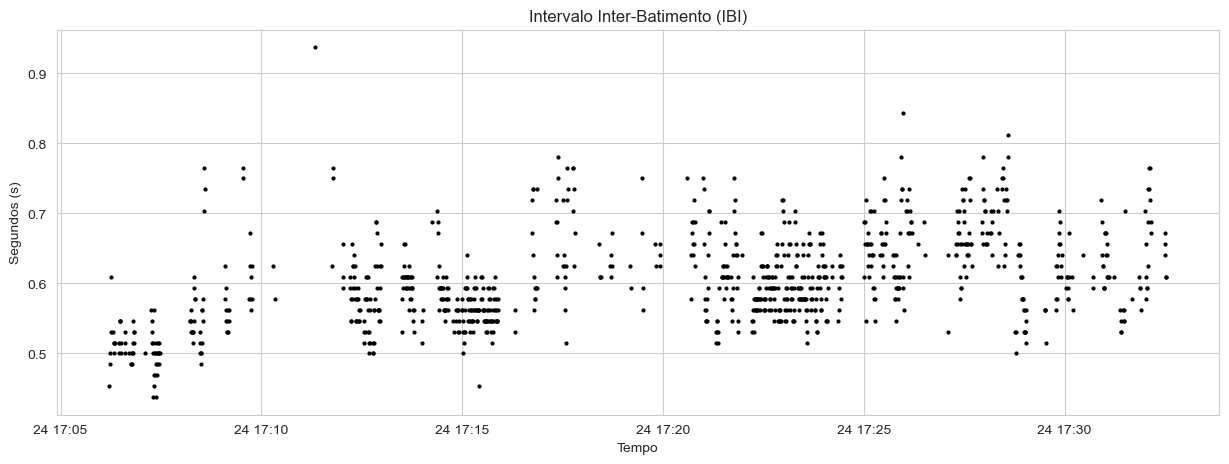

In [9]:
from scripts.analise_exploratoria import plot_sample_signals

plot_sample_signals(df_hr, df_eda, df_temp, df_acc, df_bvp, df_ibi)

##### 3.3. Gráfico Avançado: Correlação e Eventos (`tags.csv`)
O arquivo `tags.csv` é importante para conectar os dados brutos aos estados fisiológicos (Stress, Aerobic, etc.). Ele marca os momentos em que um botão físico foi pressionado no dispositivo para marcar algum evento.

Vamos carregar esses marcadores e sobrepô-los aos sinais para ver como os sinais reagem.


--- 13 Marcadores de Evento encontrados para U_79201 ---


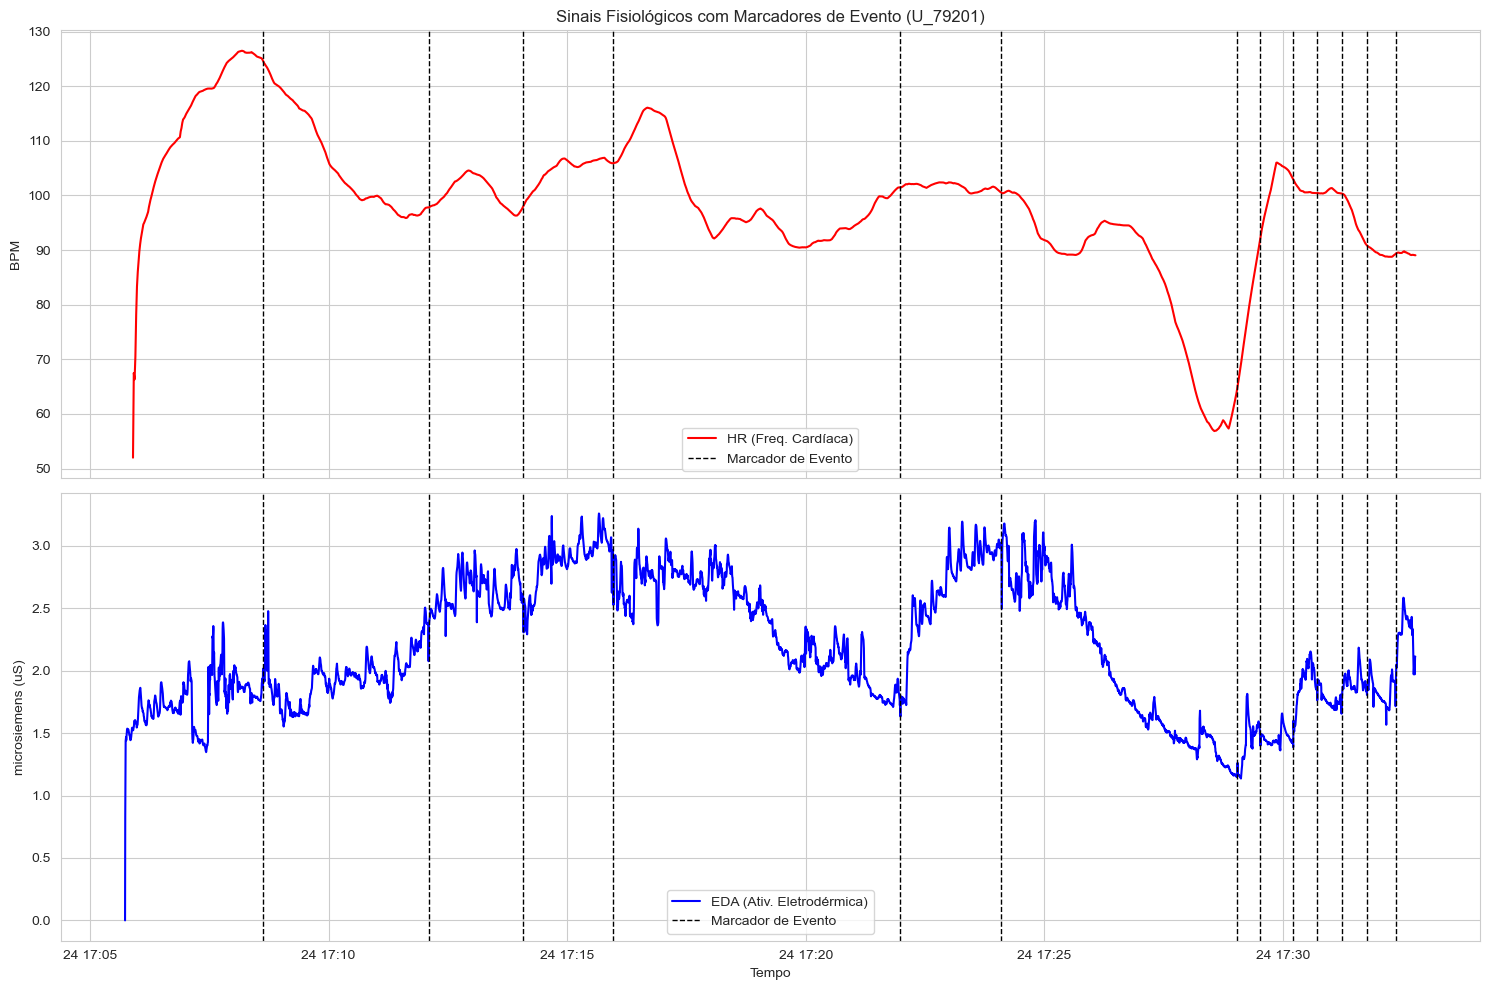

In [10]:
from scripts.analise_exploratoria import plot_signals_with_tags

plot_signals_with_tags(df_hr, df_eda, USER_ID, USER_FOLDER)

---
### Pré-processamento

Nesta seção, as funções da etapa de pré-processamento dos dados devem ser implementadas e aplicadas (se necessário).

#### **1. Processamento dos Conjuntos de Treino e Teste**
Vamos iterar pelos arquivos `train.csv` e `test.csv` para construir nossos DataFrames de features.

In [3]:
from scripts.preprocessamento import create_feature_matrices

# Definir o caminho para a pasta de dados
FILES_DIRECTORY = "dados"
WEARABLES_FOLDER = f'{FILES_DIRECTORY}/wearables/'

df_train_labels = pd.read_csv(os.path.join(FILES_DIRECTORY, 'train.csv'))
df_test_ids = pd.read_csv(os.path.join(FILES_DIRECTORY, 'test.csv'))

X_raw, y_labels, X_test_raw = create_feature_matrices(
    df_train_labels, df_test_ids, WEARABLES_FOLDER
)

print("\nEngenharia de Atributos Concluída!")
print("Shape X_raw (treino):", X_raw.shape)
print("Shape X_test_raw (teste):", X_test_raw.shape)

# Exibir as primeiras linhas da sua nova tabela de features
print("\n--- Features Geradas (X_raw) ---")
display(X_raw.head())

Processando dados de TREINO...


100%|██████████| 75/75 [03:24<00:00,  2.72s/it]


Processando dados de TESTE...


100%|██████████| 25/25 [01:22<00:00,  3.30s/it]


Engenharia de Atributos Concluída!
Shape X_raw (treino): (75, 37)
Shape X_test_raw (teste): (25, 37)

--- Features Geradas (X_raw) ---


,HR_mean,HR_std,HR_min,HR_max,HR_q25,HR_q75,EDA_mean,EDA_std,EDA_min,EDA_max,...,IBI_max,IBI_q25,IBI_q75,BVP_mean,BVP_std,BVP_min,BVP_max,BVP_q25,BVP_q75,IBI_rmssd
Id,,,,,,,,,,,,,,,,,,,,,
U_79201,98.881952,12.676421,52.00,126.50,93.52,104.620,2.189533,0.513896,0.0,3.258435,...,0.937500,0.562500,0.640625,0.019878,81.571814,-875.69,859.42,-34.87,34.495,0.045673
U_56491,88.239135,19.891537,61.83,140.27,73.22,98.375,0.694660,0.665842,0.0,2.233796,...,1.046875,0.535156,0.921875,0.021129,65.304652,-626.35,540.11,-19.76,20.420,0.120337
U_94628,105.976423,19.887857,61.29,146.28,90.38,119.570,4.049414,3.069773,0.0,9.412058,...,1.140625,0.484375,0.609375,0.009284,63.464987,-727.50,628.35,-26.47,28.750,0.065383
U_97819,84.828580,11.068379,60.55,137.75,76.74,91.320,5.359223,5.372092,0.0,20.911053,...,1.250000,0.609375,0.734375,0.029009,74.716665,-935.50,617.35,-22.60,28.790,0.097257
U_96956,79.585647,6.231371,56.48,96.42,76.52,83.590,0.670235,0.492188,0.0,2.703071,...,1.453125,0.687500,0.781250,0.001245,41.693951,-1336.85,1000.38,-12.95,13.180,0.056268


#### **2. Conversão para o Modelo (Lidando com Problemas)**
Agora temos os DataFrames `X_raw` e `X_test_raw`. Eles são a base para o modelo, mas precisamos finalizar o pré-processamento, como lidar com valores ausentes e normalizar as features.

In [4]:
from scripts.preprocessamento import apply_sklearn_pipeline

X_train, y, X_test, le, X_train_imputed_df = apply_sklearn_pipeline(X_raw, y_labels, X_test_raw)


Classes do LabelEncoder: ['AEROBIC' 'ANAEROBIC' 'STRESS']
Shape de y (alvo): (75,)

Tratamento de Valores Ausentes (Imputação) Concluído.
Escalonamento (RobustScaler) Concluído!
Shape final de X_train: (75, 37)
Shape final de X_test: (25, 37)


#### **3. Análise e Tratamento de Outliers**

Antes de treinar os modelos, vamos analisar a distribuição das features extraídas (após a imputação, mas antes do escalonamento) para identificar outliers. Usar o `RobustScaler` (feito no passo anterior) ajuda o modelo a ser menos sensível a esses pontos extremos, em vez de removê-los, o que é uma boa estratégia quando temos poucas amostras.


--- Análise Visual de Outliers (Features vs. Classe) ---


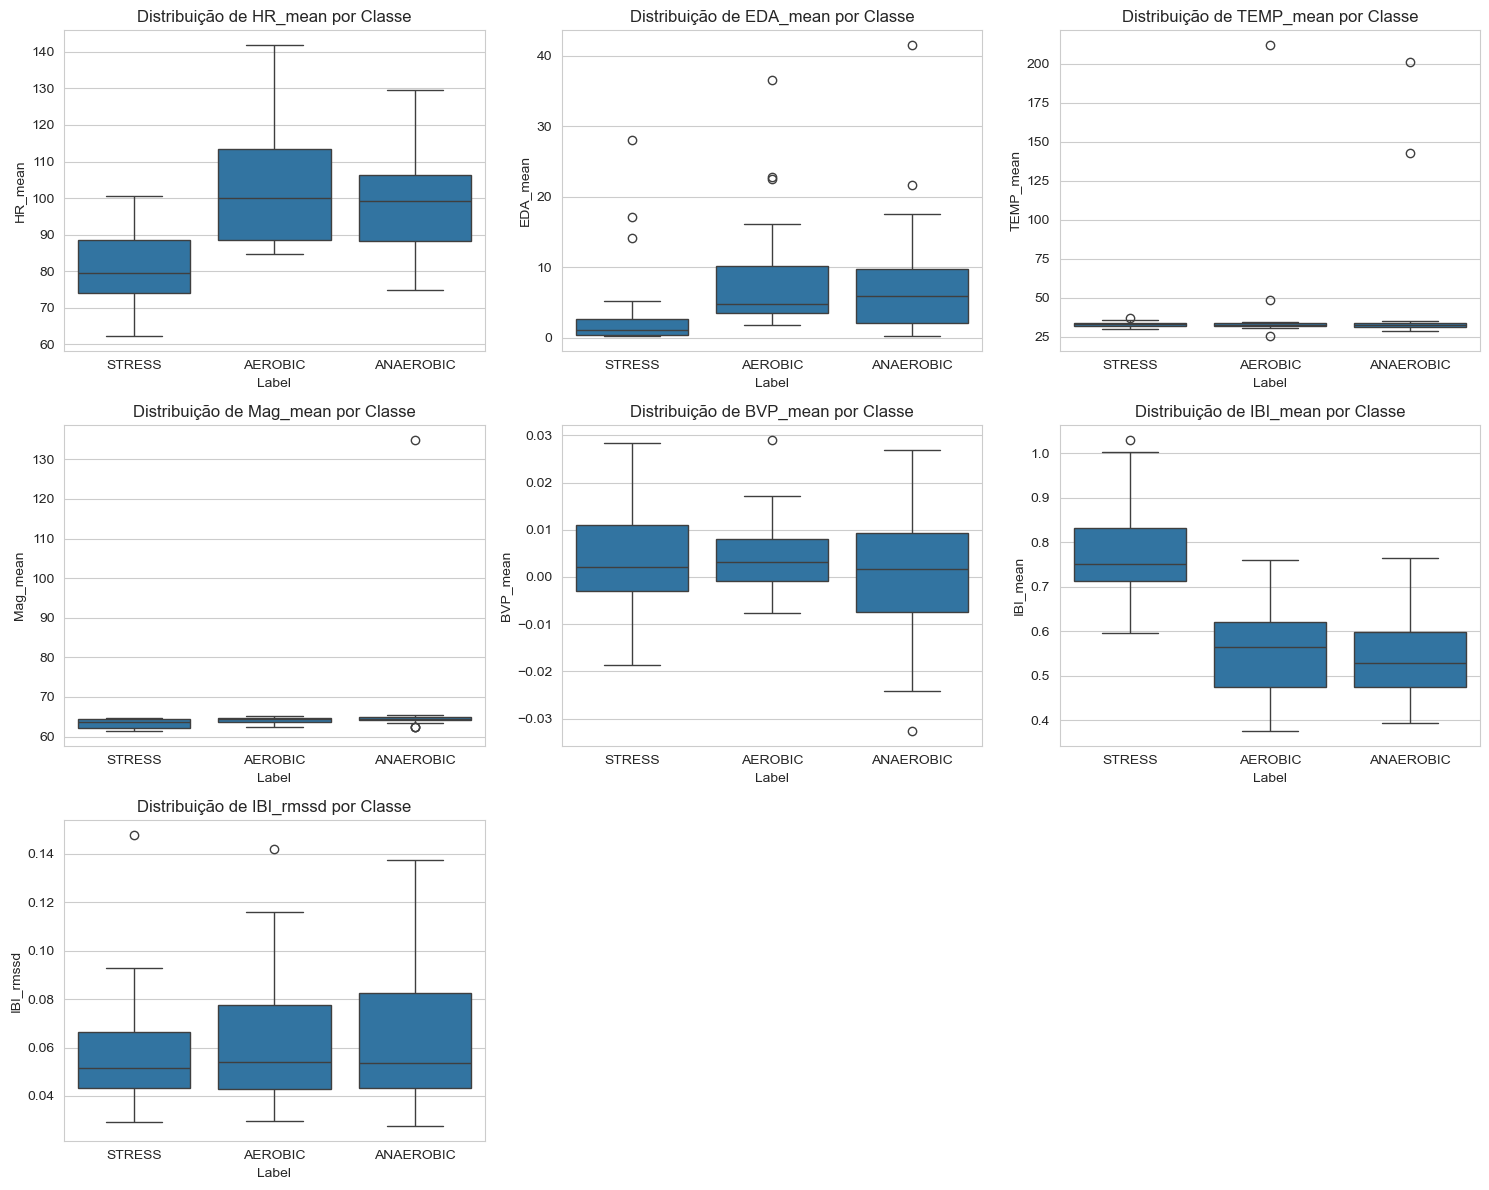

In [5]:
from scripts.preprocessamento import plot_feature_outliers_by_class

plot_feature_outliers_by_class(X_train_imputed_df, y_labels)

---
### Experimento

Nesta seção, o experimento deve ser conduzido, utilizando os protocolos experimentais padrões e testando diferentes modelos.

#### **1. Definição dos Modelos e Ajuste Fino**
Criamos um dicionário chamado `models` com cada modelo que utilizaremos (`KNN`, `Naive Bayes`, `Regressão Logística`, `SVM`, `Rede Neural` e `XGBoost`). Cada entrada contém o nome do modelo e o objeto do classificador com suas configurações. Após isso, utilizamos `Grid Search` nos modelos ajustar os hiperparâmetros, com um protocolo de validação cruzada (`StratifiedKFold`).

In [6]:
from scripts.experimentos import get_models, get_param_grids, tune_all_models

# Pega os modelos base
models = get_models()
# Pega as grades de parâmetros
param_grids = get_param_grids()

# Roda o GridSearchCV para todos os modelos
# tuned_models contém os objetos de modelo já treinados com os melhores params
# tuned_scores contém as médias de AUC de cada um (do grid search)
tuned_models, tuned_scores = tune_all_models(X_train, y, models, param_grids)


--- Iniciando Ajuste Fino de Hiperparâmetros (GridSearchCV) ---
Ajustando: Regressão Logística...
  Melhores Parâmetros: {'C': 100, 'solver': 'liblinear'}
Ajustando: k-Vizinhos (KNN)...
  Melhores Parâmetros: {'n_neighbors': 11}
Ajustando: Naive Bayes (Gauss.)...
  Melhores Parâmetros: {'var_smoothing': 1e-09}
Ajustando: SVM (RBF Kernel)...
  Melhores Parâmetros: {'C': 100, 'gamma': 0.01}
Ajustando: Rede Neural (MLP)...
  Melhores Parâmetros: {'alpha': 0.01, 'hidden_layer_sizes': (50,)}
Ajustando: XGBoost...
  Melhores Parâmetros: {'learning_rate': 0.1, 'n_estimators': 100}

--- Ajuste Fino Concluído ---


#### **2. Geração do Boxplot e Escolha do Melhor Modelo**

Com os resultados do ajuste fino, primeiro imprimimos a média da AUC para cada modelo, ordenados do melhor para o pior. Em seguida, geramos um gráfico de boxplot rodando a validação cruzada nos modelos já otimizados.


Iniciando Validação Cruzada (K-Fold) nos modelos OTIMIZADOS...
Avaliando: Regressão Logística (Otimizado)...
Avaliando: k-Vizinhos (KNN) (Otimizado)...
Avaliando: Naive Bayes (Gauss.) (Otimizado)...
Avaliando: SVM (RBF Kernel) (Otimizado)...
Avaliando: Rede Neural (MLP) (Otimizado)...
Avaliando: XGBoost (Otimizado)...

Validação Cruzada Concluída.

--- Média da AUC (ROC One-vs-Rest) de cada Modelo Otimizado (Ordenado) ---
Regressão Logística     0.836011
SVM (RBF Kernel)        0.835033
Rede Neural (MLP)       0.792375
Naive Bayes (Gauss.)    0.791567
XGBoost                 0.782108
k-Vizinhos (KNN)        0.751165
dtype: float64


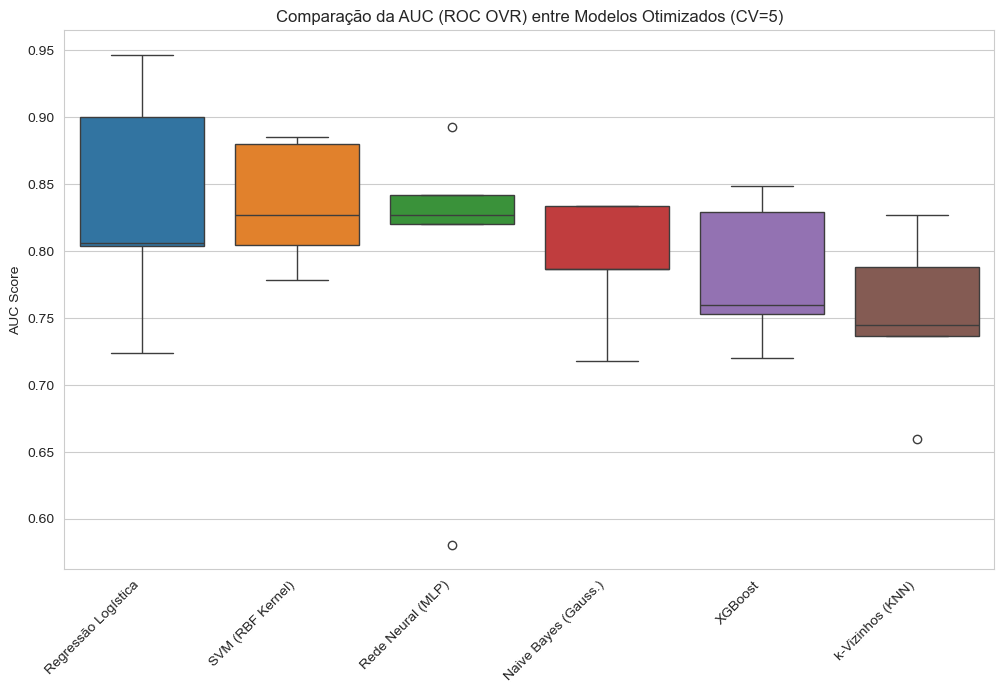

In [7]:
from scripts.experimentos import run_cross_validation, plot_cv_results

# Agora, rodamos a CV (k=5) nos modelos já otimizados para gerar os scores do boxplot
cv_results_mean, cv_results = run_cross_validation(X_train, y, tuned_models)

# O plot_cv_results agora mostra o boxplot dos modelos otimizados
mean_scores_sorted, best_model_name = plot_cv_results(cv_results, cv_results_mean)

#### **3. Geração do Arquivo de Submissão**
Após identificar o melhor modelo, geramos o arquivo de submissão

In [ ]:
from scripts.experimentos import generate_submission_file

target_order = ['STRESS', 'AEROBIC', 'ANAEROBIC']
submission_filename = 'submission.csv' 

# --- Seleção Manual do Modelo ---
manual_model_name = 'Rede Neural (MLP)'
manual_model_object = tuned_models[manual_model_name] 

print(f"Submetendo o modelo: {manual_model_name}")
# ---------------------------------

generate_submission_file(
    manual_model_object,          
    manual_model_name,     
    X_test, 
    le, 
    df_test_ids, 
    target_order, 
    submission_filename
)


Submetendo o modelo: Rede Neural (MLP)

--- Usando o Modelo Vencedor Otimizado (Rede Neural (MLP)) ---
Previsões (probabilidades) geradas para o conjunto de teste.
Ordem do Modelo: ['AEROBIC', 'ANAEROBIC', 'STRESS']
Ordem Alvo: ['STRESS', 'AEROBIC', 'ANAEROBIC']

Arquivo de submissão 'submission.csv' salvo com sucesso!
        Id  Predicted_0  Predicted_1  Predicted_2
0  U_19341     0.990466     0.009483     0.000050
1  U_54670     0.637637     0.342211     0.020152
2  U_21920     0.994245     0.003460     0.002295
3  U_58128     0.020020     0.782715     0.197264
4  U_73365     0.001029     0.215659     0.783312


---
### Análise dos Resultados

Nesta seção, os resultados devem ser exibidos através de tabelas e gráficos, comparados e profundamente analisados.

#### **1. Comparação Estatística (Validação Cruzada Local)**

A primeira etapa da análise é comparar o desempenho dos modelos otimizados usando os scores da nossa Validação Cruzada (CV) local.

Uma análise visual do boxplot (da seção anterior) revela insights importantes sobre a estabilidade do modelo:
* **Regressão Logística (LR) e SVM:** Apresentam o desempenho médio mais alto no CV (ambos com AUC ~83.5%). No entanto, suas caixas e bigodes são visivelmente mais amplos, indicando uma variabilidade maior no desempenho entre os 5 folds.
* **Rede Neural (MLP):** Apresentou a menor média de AUC (79.2%) entre os três principais. Contudo, seu boxplot é extremamente comprimido (o menor de todos), indicando um desempenho muito estável e consistente entre os folds, apesar de alguns outliers.

Para verificar se as diferenças entre os modelos são estatisticamente significativas ou coincidência(devido ao pequeno N=75), aplicamos o Teste de Friedman. Se o p-valor for < 0.05, usamos um teste post-hoc de Wilcoxon para comparar os pares mais relevantes.

In [25]:
from scripts.analise_resultados import plot_statistical_comparison

plot_statistical_comparison(cv_results, mean_scores_sorted)


--- Análise Estatística dos Modelos (Teste de Friedman) ---
Estatística de Friedman: 7.069, p-valor: 0.216
Resultado (Friedman): p-valor >= 0.05. NÃO há diferença estatística significativa entre os modelos.


**Resultado do Teste de Friedman: p-valor = 0.216**

Como o p-valor (0.216) é muito maior que 0.05, não podemos rejeitar a hipótese nula. Isso significa que, apesar das diferenças visuais e nas médias, não há diferença estatisticamente significativa entre o desempenho de nossos modelos (SVM, LR, MLP) no conjunto de dados local.

#### **2. Análise de Desempenho Individual (Placar Kaggle)**

Dado que nossa Validação Cruzada (baseada em N=75) resultou em um empate estatístico, ela não é o único critério confiável para selecionar um único vencedor. Nesses casos, o Placar Público do Kaggle torna-se o critério de desempate, pois usa dados que o modelo nunca viu (25 amostras de teste, com ~12 usadas para o placar público).

Os resultados no Kaggle mostraram o seguinte:
1.  **Rede Neural (MLP): 96.1% (Vencedor)**
2.  **SVM (RBF Kernel): 94.4%**
3.  **Regressão Logística: 84.0%**

Isso traz análises importantes: o modelo com a menor média de CV (MLP) entre os três vencedores, mas com a performance mais estável (boxplot menor), alcançou o melhor resultado no Placar Público. Isso sugere que a consistência do MLP permitiu que ele generalizasse melhor para os dados de teste do que os modelos LR e SVM, que foram mais instáveis.

Com base nisso, selecionamos a **Rede Neural (MLP)** como nosso modelo campeão para a análise individual.

##### Matriz de Confusão (Rede Neural)

Geramos uma Matriz de Confusão usando `cross_val_predict` para entender onde o modelo MLP está acertando e errando nas suas previsões locais.


--- Análise Individual (Matriz de Confusão) ---
Gerando previsões K-Fold para o modelo: MLPClassifier
Matriz de Confusão (Linhas=Verdadeiro, Colunas=Previsto):


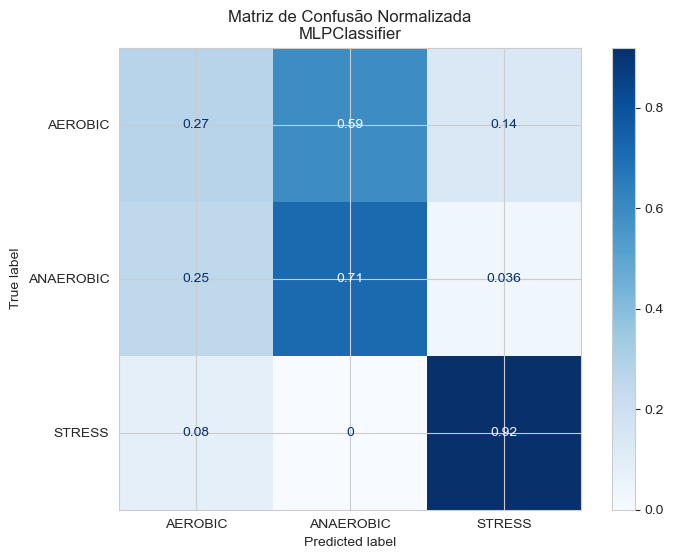

In [26]:
from scripts.analise_resultados import plot_confusion_matrix

# Selecionamos o modelo vencedor do Kaggle (MLP)
model_name_kaggle = "Rede Neural (MLP)" 
model_object_kaggle = tuned_models[model_name_kaggle] # Objeto já treinado/otimizado

# Gerar o plot (X_train e y são do pré-processamento, le é o LabelEncoder)
plot_confusion_matrix(model_object_kaggle, X_train, y, le.classes_)

A Matriz de Confusão nos mostra onde o modelo MLP está acertando e errando:

* **Desempenho Excelente em STRESS:** O modelo é extremamente eficaz em identificar a classe **STRESS (0)**, com uma taxa de acerto de 92%. As poucas confusões são mínimas.
* **Desempenho Bom em ANAEROBIC:** O modelo também tem um bom desempenho na classe **ANAEROBIC (2)**, acertando 71% das vezes, embora confunda 25% com AEROBIC.
* **Principal Ponto de Falha (AEROBIC):** A maior dificuldade do modelo está na classe **AEROBIC (1)**, que ele acerta apenas 27%* das vezes. A maioria dos erros (59%) é classificada incorretamente como ANAEROBIC.

**Conclusão (Matriz):** O modelo é robusto para o objetivo principal de detectar estresse. Sua maior limitação é a dificuldade em distinguir a intensidade do esforço físico, confundindo massivamente AEROBIC com ANAEROBIC.

##### Importância das Features (Rede Neural)

Agora, analisamos o que o modelo MLP aprendeu. Usamos a Importância por Permutação, que mede o quanto a AUC do modelo cai quando embaralhamos uma feature de cada vez. Features que causam uma queda maior são as mais importantes.


--- Análise de Importância das Features (Permutation Importance) ---


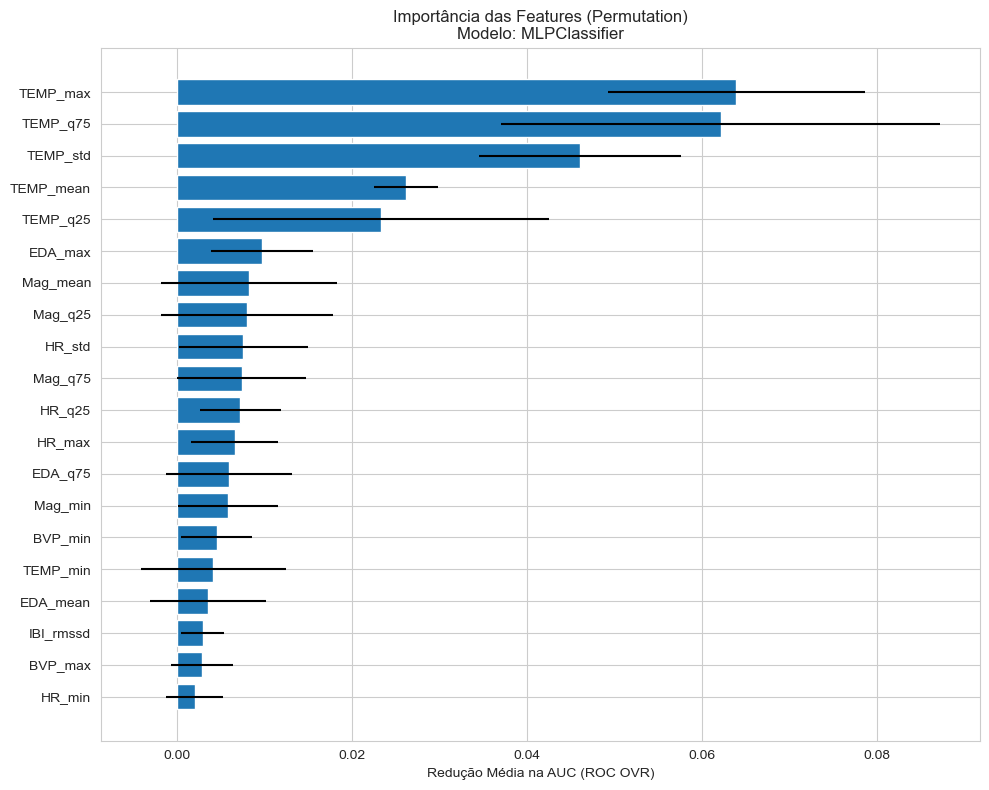

In [27]:
from scripts.analise_resultados import plot_feature_importance

feature_names = X_raw.columns

# Usamos o mesmo modelo MLP e dados de treino
plot_feature_importance(model_object_kaggle, X_train, y, feature_names)

A análise de Importância por Permutação revela quais features o MLP usou para alcançar seu resultado:

1.  **Temperatura da Pele (TEMP):** Este foi de longe o sinal mais preditivo. Todas as estatísticas de temperatura (`TEMP_max`, `TEMP_q75`, `TEMP_std`, `TEMP_mean`) dominaram o topo do gráfico. Isso sugere que variações térmicas são um forte diferenciador entre estresse e esforço.
2.  **Atividade Eletrodérmica (EDA):** A feature `EDA_max` apareceu em seguida.
3.  **Acelerômetro (ACC):** As estatísticas de magnitude (`Mag_mean`, `Mag_q75`, etc.) também foram relevantes, ajudando o modelo a identificar o nível de movimento físico (Esforço vs. Estresse).

**Conclusão (Features):** O modelo aprendeu a focar primariamente na Temperatura, complementada pelo EDA e pelo Movimento (ACC). Curiosamente, as features de HRV (como `IBI_rmssd`) e BVP tiveram baixa importância, sugerindo que as estatísticas simples extraídas podem não ter capturado sua complexidade total.

#### 3. **Conclusões Finais**

A análise final revelou uma discrepância significativa entre a Validação Cruzada (CV) local e o Placar Público do Kaggle, um sintoma clássico da modelagem em datasets com poucas amostras de treinamento (N=75).

Enquanto o CV local apontava um empate estatístico (Teste de Friedman, p=0.216), ele também mostrava que a Rede Neural (MLP) era o modelo mais estável (boxplot mais comprimido), apesar de sua média de AUC ser a 3ª colocada (79.2%).

Essa estabilidade se provou um fator decisivo: no conjunto de teste externo, o MLP alcançou o maior score no Kaggle (96.1%), superando o SVM (94.4%) e o LR (84.0%).

O modelo MLP vencedor demonstrou (via Matriz de Confusão) ser excelente na detecção de STRESS (92% de acerto), embora tenha dificuldade em separar as intensidades de esforço (AEROBIC vs. ANAEROBIC). Para isso, o modelo aprendeu a focar (via Importância das Features) primariamente nas variações de Temperatura da Pele (TEMP), complementadas por picos de Atividade Eletrodérmica (EDA) e pela Magnitude do Movimento (ACC).

Para a submissão final da competição, o MLP e o SVM (segundo colocado) são os candidatos mais fortes e confiáveis.